# 03 — Model Training, Two-Mode Evaluation, K-Fold, and Best Model Selection — Revised v5

**Competition metric:** Model Performance / Evaluation Metrics (20%).

Notebook ini melatih model klasifikasi untuk memprediksi `readiness_label` dari Notebook 02. Karena label yang digunakan adalah **pseudo label**, evaluasi dibuat lebih hati-hati dengan dua mode:

1. **Rule-replication mode**: fitur boleh memakai komponen rule seperti `dea_score_filled`, `rc_viability_score`, dan `crisis_resilience_score`. Tujuannya menguji apakah model dapat mereplikasi decision engine secara konsisten.
2. **Operational-prediction mode**: fitur skor rule, cluster support, dan readiness score dikeluarkan. Tujuannya menguji apakah pseudo label masih dapat diprediksi dari fitur operasional supply chain yang tersedia di dataset.

Revisi utama:

- split train-test dilakukan **sebelum** K-Fold,
- K-Fold dijalankan hanya pada train set,
- menggunakan **Stratified 5-Fold** jika jumlah kelas memungkinkan,
- model dibandingkan dengan Macro F1 dan Balanced Accuracy,
- model akhir yang diekspor adalah model terbaik dari **Operational-prediction mode** karena lebih defensible untuk skenario prediksi.

In [13]:
from pathlib import Path
import json, warnings, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.preprocessing import OneHotEncoder, RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
PLOT_DIR = OUTPUT_DIR / 'plots'
MODEL_DIR = OUTPUT_DIR / 'models'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (10, 5.8),
    'figure.dpi': 120,
    'savefig.dpi': 180,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'axes.labelsize': 10,
    'axes.titlesize': 14,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'grid.alpha': 0.25,
    'legend.frameon': False,
})

COLORS = {'blue':'#457b9d', 'green':'#2a9d8f', 'orange':'#e9c46a', 'red':'#e76f51', 'ink':'#1f2937'}
LABEL_ORDER = ['Not Recommended', 'Conditional', 'Recommended']

def savefig(name):
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()

print('Project root:', PROJECT_ROOT)
print('Output dir:', OUTPUT_DIR)

Project root: c:\Users\USER\Documents\VSCODE\riceguard_notebooks
Output dir: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs


## 1. Load modeling dataset

Jika file tidak ditemukan, jalankan urutan:

`Notebook 01 → Notebook 02 → Notebook 03`

In [14]:
modeling_path = OUTPUT_DIR / '02_modeling_dataset.csv'
if not modeling_path.exists():
    raise FileNotFoundError('outputs/02_modeling_dataset.csv tidak ditemukan. Jalankan Notebook 01 dan 02 terlebih dahulu.')

df = pd.read_csv(modeling_path)
TARGET = 'readiness_label'
if TARGET not in df.columns:
    raise ValueError(f'Target {TARGET} tidak ditemukan di modeling dataset.')

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=[TARGET]).copy()
df[TARGET] = df[TARGET].astype(str)

label_order = [x for x in LABEL_ORDER if x in df[TARGET].unique()]
print('Dataset shape:', df.shape)
print('Target distribution:')
display(df[TARGET].value_counts().reindex(label_order).rename_axis(TARGET).reset_index(name='count'))
display(df.head())

Dataset shape: (815, 79)
Target distribution:


,readiness_label,count
0,Not Recommended,268
1,Conditional,374
2,Recommended,173


,actor,region,dmu,total_cost,output_value,margin,rc_ratio,margin_ratio,quantity_proxy,cost_per_quantity,output_per_quantity,asset_proxy,asset_utilization,dea_score,dea_score_filled,rc_viability_score,margin_score,asset_utilization_score,cost_burden_score,crisis_resilience_score,crisis_sensitivity_score,cluster,cluster_support_score,readiness_score,readiness_label,vote_ready,vote_high_risk,label_reason,source_row,land_area,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr,dmu_original,dmu_auto_assigned,number_of_machines,value_of_milled_grains_idr,amount_of_milled_rice,supporting_equipment_cost_idr,value_of_milled_rice_idr,total_revenue_of_milling_machine_idr,total_rice_purchase_kg,total_rice_purchase_value_idr,building_rent_cost_idr,value_of_rice_sold_idr,total_precipitation,precipitation_quality,value_of_rice_purchase_idr,cost_to_output_ratio,labor_cost_share,building_rent_share,land_lease_share,supporting_equipment_share,equipment_rent_share,seed_cost_share,fertilizer_cost_share,pesticide_cost_share,rice_purchase_share,milled_grain_purchase_share,log_total_cost,log_output_value,log_quantity_proxy,log_asset_proxy,log_abs_margin,is_margin_negative,is_rc_below_one,cost_burden_raw,survive_cost_up_10,survive_output_down_10,survive_cost_up_20,survive_output_down_20,survive_cost_up_30,survive_output_down_30,survive_combined_10,survive_combined_20
0,Farmer,Garut,1,"11,418,000.0000","16,200,000.0000","4,782,000.0000",1.4188,0.4188,"2,800.0000","4,077.8571","5,785.7143","2,800.0000","5,785.7143",0.1543,0.1543,1.0000,0.2200,0.1462,0.2175,0.7500,0.2500,2,0.0000,0.4064,Conditional,2,2,low DEA efficiency; weak margin health; weak a...,2,"2,800.0000","4,900,000.0000","1,400,000.0000","644,000.0000","3,640,000.0000","364,000.0000","470,000.0000","16,200,000.0000",1.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7048,0.1226,NaN,0.4291,NaN,0.0412,0.0564,0.3188,0.0319,NaN,NaN,16.2507,16.6005,7.9377,7.9377,15.3804,0,0,0.7048,1,1,1,1,1,0,1,0
1,Farmer,Garut,2,"8,264,000.0000","8,100,000.0000","-164,000.0000",0.9802,-0.0198,"1,400.0000","5,902.8571","5,785.7143","1,400.0000","5,785.7143",0.1277,0.1277,0.7841,0.0825,0.1462,0.0800,0.0000,1.0000,2,0.0000,0.2221,Not Recommended,0,4,low DEA efficiency; weak margin health; high c...,3,"1,400.0000","4,900,000.0000","500,000.0000","322,000.0000","1,820,000.0000","182,000.0000","540,000.0000","8,100,000.0000",2.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0202,0.0605,NaN,0.5929,NaN,0.0653,0.0390,0.2202,0.0220,NaN,NaN,15.9274,15.9074,7.2449,7.2449,12.0076,1,1,1.0202,0,0,0,0,0,0,0,0
2,Farmer,Garut,3,"6,450,000.0000","14,850,000.0000","8,400,000.0000",2.3023,1.3023,"2,000.0000","3,225.0000","7,425.0000","2,000.0000","7,425.0000",0.2225,0.2225,1.0000,0.5700,0.3412,0.5675,1.0000,0.0000,2,0.0000,0.5364,Conditional,2,1,low DEA efficiency; weak asset utilization; we...,4,"2,000.0000","2,000,000.0000","700,000.0000","200,000.0000","2,600,000.0000","260,000.0000","690,000.0000","14,850,000.0000",3.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4343,0.1085,NaN,0.3101,NaN,0.1070,0.0310,0.4031,0.0403,NaN,NaN,15.6796,16.5135,7.6014,7.6014,15.9437,0,0,0.4343,1,1,1,1,1,1,1,1
3,Farmer,Garut,4,"4,570,000.0000","13,050,000.0000","8,480,000.0000",2.8556,1.8556,"1,000.0000","4,570.0000","13,050.0000","1,000.0000","13,050.0000",0.3000,0.3000,1.0000,0.7475,0.6825,0.7450,1.0000,0.0000,1,1.0000,0.7204,Recommended,3,1,low DEA efficiency,5,"1,000.0000","1,800,000.0000","800,000.0000","230,000.0000","1,300,000.0000","100,000.0000","340,000.0000","13,050,000.0000",4.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3502,0.1751,NaN,0.3939,NaN,0.0744,0.0503,0.2845,0.0219,NaN,NaN,15.3350,16.3843,6.9088,6.9088,15.9532,0,0,0.3502,1,1,1,1,1,1,1,1
4,Farmer,Garut,5,"3,778,000.0000","10,200,000.0000","6,422,000.0000",2.6998,1.6998,800.0000,"4,722.5000","12,750.

## 2. Define two evaluation modes

Pseudo label berasal dari rule. Karena itu, model dievaluasi dalam dua mode:

| Mode | Tujuan | Fitur yang digunakan |
|---|---|---|
| `rule_replication` | menguji apakah model bisa mereplikasi rule engine | fitur operasional + skor rule seperti DEA/R/C/crisis |
| `operational_prediction` | mengurangi pseudo-label leakage | fitur operasional/raw, tanpa final score, rule component score, cluster support, vote, dan survival scenario |

Mode kedua lebih penting untuk submission karena menunjukkan model tidak hanya membaca ulang skor final pembentuk label.

In [15]:
# Columns that should never enter features.
always_exclude = {
    TARGET, 'readiness_label', 'readiness_score', 'label_reason',
    'dmu_original', 'source_row'
}

# Rule/label-construction components excluded from operational mode.
rule_component_exclude = {
    'dea_score', 'dea_score_filled',
    'rc_viability_score', 'margin_score', 'asset_utilization_score', 'cost_burden_score',
    'cost_burden_raw', 'crisis_resilience_score', 'crisis_sensitivity_score',
    'cluster', 'cluster_support_score',
    'vote_ready', 'vote_high_risk'
}
rule_component_exclude.update([c for c in df.columns if c.startswith('survive_')])

# Extra metadata columns not useful as predictors.
metadata_exclude = {'dmu_auto_assigned'}

feature_modes = {}
feature_modes['rule_replication'] = [
    c for c in df.columns
    if c not in always_exclude and c not in {'dmu_original'}
]
feature_modes['operational_prediction'] = [
    c for c in df.columns
    if c not in always_exclude
    and c not in rule_component_exclude
    and c not in metadata_exclude
]

for mode, cols in feature_modes.items():
    print()
    print(f'{mode}: {len(cols)} features')
    print(cols[:40], '...' if len(cols) > 40 else '')


rule_replication: 74 features
['actor', 'region', 'dmu', 'total_cost', 'output_value', 'margin', 'rc_ratio', 'margin_ratio', 'quantity_proxy', 'cost_per_quantity', 'output_per_quantity', 'asset_proxy', 'asset_utilization', 'dea_score', 'dea_score_filled', 'rc_viability_score', 'margin_score', 'asset_utilization_score', 'cost_burden_score', 'crisis_resilience_score', 'crisis_sensitivity_score', 'cluster', 'cluster_support_score', 'vote_ready', 'vote_high_risk', 'land_area', 'land_lease_value_idr', 'labor_cost_idr', 'seed_purchase_value_idr', 'fertilizer_purchase_value_idr', 'pesticide_purchase_value_idr', 'equipment_rent_value_idr', 'production_value_idr', 'dmu_auto_assigned', 'number_of_machines', 'value_of_milled_grains_idr', 'amount_of_milled_rice', 'supporting_equipment_cost_idr', 'value_of_milled_rice_idr', 'total_revenue_of_milling_machine_idr'] ...

operational_prediction: 52 features
['actor', 'region', 'dmu', 'total_cost', 'output_value', 'margin', 'rc_ratio', 'margin_ratio', 

## 3. Train-test split before K-Fold

Holdout dipisahkan terlebih dahulu. Model selection dilakukan dengan K-Fold pada train set saja, lalu model terbaik dievaluasi satu kali pada holdout test set.

In [16]:
y = df[TARGET]
stratify_arg = y if y.value_counts().min() >= 2 else None
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.25,
    random_state=42,
    stratify=stratify_arg
)
train_df = df.loc[train_idx].copy()
test_df = df.loc[test_idx].copy()

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print()
print('Train target distribution:')
display(train_df[TARGET].value_counts().reindex(label_order).rename_axis(TARGET).reset_index(name='count'))
print()
print('Test target distribution:')
display(test_df[TARGET].value_counts().reindex(label_order).rename_axis(TARGET).reset_index(name='count'))

Train shape: (611, 79)
Test shape : (204, 79)

Train target distribution:


,readiness_label,count
0,Not Recommended,201
1,Conditional,280
2,Recommended,130



Test target distribution:


,readiness_label,count
0,Not Recommended,67
1,Conditional,94
2,Recommended,43


## 4. Preprocessing and model zoo

Semua model memakai preprocessing yang sama:

- numeric: median imputation + RobustScaler,
- categorical: most frequent imputation + OneHotEncoder.

Model utama yang dijalankan default adalah model tabular yang relatif ringan dan stabil. XGBoost, LightGBM, dan CatBoost tetap disediakan di kode sebagai optional boosters, tetapi dilindungi oleh flag `ENABLE_OPTIONAL_BOOSTERS`. Pada beberapa environment, booster package bisa sangat lambat/hang; untuk kompetisi/Kaggle/Colab, ubah flag menjadi `True` jika package tersedia dan runtime cukup.


In [17]:
def make_onehot():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

class EncodedYClassifier(BaseEstimator, ClassifierMixin):
    """Wrapper for classifiers that need integer labels, e.g., XGBoost."""
    def __init__(self, estimator):
        self.estimator = estimator
    def fit(self, X, y):
        self.label_encoder_ = LabelEncoder()
        y_enc = self.label_encoder_.fit_transform(y)
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, y_enc)
        self.classes_ = self.label_encoder_.classes_
        return self
    def predict(self, X):
        pred = self.estimator_.predict(X)
        pred = np.asarray(pred).astype(int)
        return self.label_encoder_.inverse_transform(pred)
    def predict_proba(self, X):
        if hasattr(self.estimator_, 'predict_proba'):
            return self.estimator_.predict_proba(X)
        raise AttributeError('Wrapped estimator has no predict_proba')


def has_package(name):
    return importlib.util.find_spec(name) is not None

# Heavy boosters are available in code but disabled by default for runtime stability.
# Set to True in Kaggle/Colab when xgboost/lightgbm/catboost are installed and time allows.
ENABLE_OPTIONAL_BOOSTERS = True


def build_preprocessor(X):
    cat_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    num_features = [c for c in X.columns if c not in cat_features]
    numeric_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ])
    categorical_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_onehot())
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_pipe, num_features),
            ('cat', categorical_pipe, cat_features)
        ],
        remainder='drop'
    )
    return preprocessor, num_features, cat_features


def build_model_zoo():
    models = {
        'Logistic Regression': LogisticRegression(max_iter=300, class_weight='balanced', solver='liblinear'),
        'Ridge Classifier': RidgeClassifier(class_weight='balanced'),
        'Decision Tree': DecisionTreeClassifier(max_depth=None, min_samples_leaf=4, class_weight='balanced', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=40, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=1),
        'Extra Trees': ExtraTreesClassifier(n_estimators=50, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=1),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=30, learning_rate=0.05, random_state=42),
        'AdaBoost': AdaBoostClassifier(n_estimators=20, learning_rate=0.05, random_state=42),
    }
    optional_status = []
    if ENABLE_OPTIONAL_BOOSTERS and has_package('xgboost'):
        try:
            from xgboost import XGBClassifier
            xgb = XGBClassifier(
                n_estimators=45,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.85,
                colsample_bytree=0.85,
                objective='multi:softprob',
                eval_metric='mlogloss',
                random_state=42,
                n_jobs=1,
                tree_method='hist',
                verbosity=0,
            )
            models['XGBoost'] = EncodedYClassifier(xgb)
            optional_status.append(('XGBoost', 'available'))
        except Exception as e:
            optional_status.append(('XGBoost', f'skipped: {e}'))
    else:
        optional_status.append(('XGBoost', 'disabled by default or not installed'))
    if ENABLE_OPTIONAL_BOOSTERS and has_package('lightgbm'):
        try:
            from lightgbm import LGBMClassifier
            models['LightGBM'] = LGBMClassifier(
                n_estimators=55,
                learning_rate=0.05,
                num_leaves=31,
                subsample=0.85,
                colsample_bytree=0.85,
                random_state=42,
                n_jobs=1,
                verbose=-1,
            )
            optional_status.append(('LightGBM', 'available'))
        except Exception as e:
            optional_status.append(('LightGBM', f'skipped: {e}'))
    else:
        optional_status.append(('LightGBM', 'disabled by default or not installed'))
    if ENABLE_OPTIONAL_BOOSTERS and has_package('catboost'):
        try:
            from catboost import CatBoostClassifier
            models['CatBoost'] = CatBoostClassifier(
                iterations=55,
                depth=4,
                learning_rate=0.04,
                loss_function='MultiClass',
                random_seed=42,
                verbose=False,
                allow_writing_files=False,
                thread_count=1,
            )
            optional_status.append(('CatBoost', 'available'))
        except Exception as e:
            optional_status.append(('CatBoost', f'skipped: {e}'))
    else:
        optional_status.append(('CatBoost', 'disabled by default or not installed'))
    return models, pd.DataFrame(optional_status, columns=['optional_model', 'status'])

models, optional_status_df = build_model_zoo()
print('Models included:', len(models))
display(optional_status_df)

Models included: 10


,optional_model,status
0,XGBoost,available
1,LightGBM,available
2,CatBoost,available


## 5. Cross-validation model selection per mode

Metric utama:

- **Macro F1**: semua kelas diperlakukan sama penting,
- **Balanced Accuracy**: lebih adil ketika pseudo label tidak seimbang,
- Accuracy dan Weighted F1 dilaporkan sebagai tambahan.

`selection_score = 0.60 × Macro F1 + 0.40 × Balanced Accuracy`.

In [18]:
scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
}

all_cv_results = []
all_failed = []
mode_artifacts = {}

for mode, feature_cols in feature_modes.items():
    X_train = train_df[feature_cols].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[feature_cols].copy()
    y_test = test_df[TARGET].copy()

    preprocessor, num_features, cat_features = build_preprocessor(X_train)
    pipes = {name: Pipeline(steps=[('preprocess', preprocessor), ('model', clf)]) for name, clf in models.items()}

    min_class = int(y_train.value_counts().min())
    n_splits = int(min(5, min_class))
    if n_splits < 2:
        raise ValueError(f'Tidak cukup data per kelas untuk Stratified K-Fold pada mode {mode}.')
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    print()
    print(f'=== Mode: {mode} | features={len(feature_cols)} | CV folds={n_splits} ===')
    cv_rows = []
    failed_rows = []
    for name, pipe in pipes.items():
        print(f'Running CV: {mode} / {name}')
        try:
            scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1, error_score='raise', return_train_score=False)
            row = {'mode': mode, 'model': name, 'n_features': len(feature_cols), 'cv_folds': n_splits}
            for metric in scoring:
                vals = scores[f'test_{metric}']
                row[f'{metric}_mean'] = float(np.mean(vals))
                row[f'{metric}_std'] = float(np.std(vals))
            row['fit_time_mean'] = float(np.mean(scores['fit_time']))
            cv_rows.append(row)
        except Exception as e:
            failed_rows.append({'mode': mode, 'model': name, 'error': str(e)[:400]})

    mode_cv = pd.DataFrame(cv_rows)
    mode_cv['selection_score'] = 0.60 * mode_cv['f1_macro_mean'] + 0.40 * mode_cv['balanced_accuracy_mean']
    mode_cv = mode_cv.sort_values(['selection_score','f1_macro_mean','balanced_accuracy_mean'], ascending=False).reset_index(drop=True)
    display(mode_cv)

    all_cv_results.append(mode_cv)
    all_failed.extend(failed_rows)
    mode_artifacts[mode] = {
        'feature_cols': feature_cols,
        'num_features': num_features,
        'cat_features': cat_features,
        'pipes': pipes,
        'n_splits': n_splits,
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'cv_results': mode_cv
    }

cv_results = pd.concat(all_cv_results, ignore_index=True).sort_values(['selection_score','f1_macro_mean'], ascending=False).reset_index(drop=True)
failed_df = pd.DataFrame(all_failed)

print()
print('Overall CV ranking:')
display(cv_results)
if not failed_df.empty:
    print()
    print('Failed models:')
    display(failed_df)

cv_results.to_csv(OUTPUT_DIR / '03_all_modes_cv_model_comparison.csv', index=False)
if not failed_df.empty:
    failed_df.to_csv(OUTPUT_DIR / '03_failed_models.csv', index=False)


=== Mode: rule_replication | features=74 | CV folds=5 ===
Running CV: rule_replication / Logistic Regression
Running CV: rule_replication / Ridge Classifier
Running CV: rule_replication / Decision Tree
Running CV: rule_replication / Random Forest
Running CV: rule_replication / Extra Trees
Running CV: rule_replication / Gradient Boosting
Running CV: rule_replication / AdaBoost
Running CV: rule_replication / XGBoost
Running CV: rule_replication / LightGBM
Running CV: rule_replication / CatBoost


,mode,model,n_features,cv_folds,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,fit_time_mean,selection_score
0,rule_replication,Extra Trees,74,5,0.9591,0.0090,0.9573,0.0074,0.9559,0.0095,0.9591,0.0086,0.0897,0.9565
1,rule_replication,LightGBM,74,5,0.9525,0.0062,0.9443,0.0021,0.9501,0.0057,0.9525,0.0060,0.2048,0.9478
2,rule_replication,Random Forest,74,5,0.9525,0.0109,0.9457,0.0113,0.9485,0.0075,0.9524,0.0105,0.1120,0.9474
3,rule_replication,Decision Tree,74,5,0.9427,0.0186,0.9445,0.0176,0.9404,0.0187,0.9429,0.0186,0.0381,0.9421
4,rule_replication,CatBoost,74,5,0.9443,0.0142,0.9310,0.0220,0.9395,0.0148,0.9440,0.0144,0.7994,0.9361
5,rule_replication,XGBoost,74,5,0.9361,0.0160,0.9263,0.0174,0.9332,0.0144,0.9360,0.0158,0.4771,0.9305
6,rule_replication,Gradient Boosting,74,5,0.9296,0.0112,0.9193,0.0167,0.9253,0.0101,0.9295,0.0111,0.4867,0.9229
7,rule_replication,Ridge Classifier,74,5,0.8740,0.0268,0.8817,0.0262,0.8731,0.0256,0.8738,0.0271,0.0318,0.8765
8,rule_replication,Logistic Regression,74,5,0.6417,0.0748,0.6637,0.1076,0.6382,0.0905,0.6342,0.0735,0.0528,0.6484
9,rule_replication,AdaBoost,74,5,0.7005,0.0193,0.5849,0.0166,0.5344,0.0159,0.6237,0.0181,0.0888,0.5546



=== Mode: operational_prediction | features=52 | CV folds=5 ===
Running CV: operational_prediction / Logistic Regression
Running CV: operational_prediction / Ridge Classifier
Running CV: operational_prediction / Decision Tree
Running CV: operational_prediction / Random Forest
Running CV: operational_prediction / Extra Trees
Running CV: operational_prediction / Gradient Boosting
Running CV: operational_prediction / AdaBoost
Running CV: operational_prediction / XGBoost
Running CV: operational_prediction / LightGBM
Running CV: operational_prediction / CatBoost


,mode,model,n_features,cv_folds,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,fit_time_mean,selection_score
0,operational_prediction,LightGBM,52,5,0.9345,0.0137,0.9303,0.0194,0.9303,0.0130,0.9345,0.0138,0.1278,0.9303
1,operational_prediction,Random Forest,52,5,0.9264,0.0115,0.9229,0.0231,0.9226,0.0165,0.9261,0.0120,0.0931,0.9227
2,operational_prediction,Extra Trees,52,5,0.9231,0.0217,0.9237,0.0173,0.9220,0.0233,0.9234,0.0215,0.0800,0.9227
3,operational_prediction,Decision Tree,52,5,0.8969,0.0185,0.9014,0.0247,0.8953,0.0185,0.8969,0.0184,0.0235,0.8977
4,operational_prediction,XGBoost,52,5,0.8822,0.0198,0.8682,0.0169,0.8777,0.0153,0.8814,0.0196,0.1200,0.8739
5,operational_prediction,Gradient Boosting,52,5,0.8870,0.0287,0.8640,0.0330,0.8798,0.0290,0.8856,0.0290,0.4003,0.8735
6,operational_prediction,CatBoost,52,5,0.8690,0.0250,0.8459,0.0284,0.8627,0.0263,0.8677,0.0255,0.6004,0.8560
7,operational_prediction,Ridge Classifier,52,5,0.8183,0.0168,0.8387,0.0131,0.8220,0.0174,0.8167,0.0179,0.0170,0.8287
8,operational_prediction,Logistic Regression,52,5,0.6385,0.0754,0.6548,0.1153,0.6298,0.0979,0.6289,0.0766,0.0295,0.6398
9,operational_prediction,AdaBoost,52,5,0.6481,0.0177,0.5537,0.0141,0.4912,0.0138,0.5722,0.0165,0.0939,0.5162



Overall CV ranking:


,mode,model,n_features,cv_folds,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,fit_time_mean,selection_score
0,rule_replication,Extra Trees,74,5,0.9591,0.0090,0.9573,0.0074,0.9559,0.0095,0.9591,0.0086,0.0897,0.9565
1,rule_replication,LightGBM,74,5,0.9525,0.0062,0.9443,0.0021,0.9501,0.0057,0.9525,0.0060,0.2048,0.9478
2,rule_replication,Random Forest,74,5,0.9525,0.0109,0.9457,0.0113,0.9485,0.0075,0.9524,0.0105,0.1120,0.9474
3,rule_replication,Decision Tree,74,5,0.9427,0.0186,0.9445,0.0176,0.9404,0.0187,0.9429,0.0186,0.0381,0.9421
4,rule_replication,CatBoost,74,5,0.9443,0.0142,0.9310,0.0220,0.9395,0.0148,0.9440,0.0144,0.7994,0.9361
5,rule_replication,XGBoost,74,5,0.9361,0.0160,0.9263,0.0174,0.9332,0.0144,0.9360,0.0158,0.4771,0.9305
6,operational_prediction,LightGBM,52,5,0.9345,0.0137,0.9303,0.0194,0.9303,0.0130,0.9345,0.0138,0.1278,0.9303
7,rule_replication,Gradient Boosting,74,5,0.9296,0.0112,0.9193,0.0167,0.9253,0.0101,0.9295,0.0111,0.4867,0.9229
8,operational_prediction,Random Forest,52,5,0.9264,0.0115,0.9229,0.0231,0.9226,0.0165,0.9261,0.0120,0.0931,0.9227
9,operational_prediction,Extra Trees,52,5,0.9231,0.0217,0.9237,0.0173,0.9220,0.0233,0.9234,0.0215,0.0800,0.9227


## 6. Visual comparison across modes

Grafik ini membantu menjawab apakah performa tinggi hanya terjadi karena rule component masuk sebagai fitur, atau tetap bagus ketika fitur rule dikeluarkan pada operational mode.

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\03_revised_model_comparison_across_modes.png


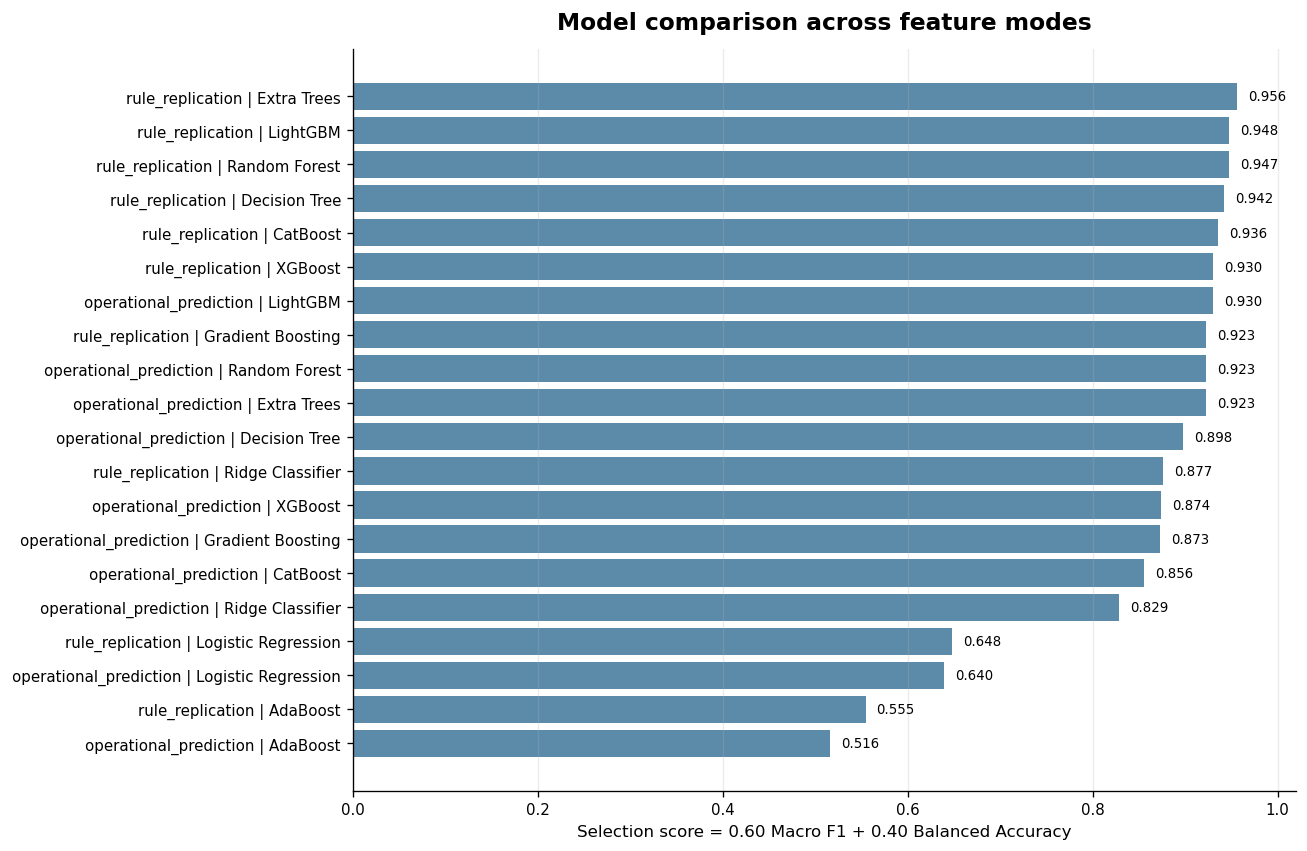

In [19]:
plot_df = cv_results.copy()
plot_df['label'] = plot_df['mode'] + ' | ' + plot_df['model']
plot_df = plot_df.sort_values('selection_score', ascending=True).tail(20)
fig, ax = plt.subplots(figsize=(11, max(6, 0.36 * len(plot_df))))
ax.barh(plot_df['label'], plot_df['selection_score'], color=COLORS['blue'], alpha=0.88)
ax.set_xlim(0, 1.02)
ax.set_xlabel('Selection score = 0.60 Macro F1 + 0.40 Balanced Accuracy')
ax.set_title('Model comparison across feature modes')
ax.grid(axis='x')
for i, (_, r) in enumerate(plot_df.iterrows()):
    ax.text(min(r['selection_score'] + 0.012, 0.98), i, f"{r['selection_score']:.3f}", va='center', fontsize=8)
savefig('03_revised_model_comparison_across_modes.png')

## 7. Holdout evaluation

Model terbaik dari setiap mode dievaluasi pada holdout test set. Untuk submission, **Operational Prediction** dipakai sebagai model utama karena lebih defensible dan lebih sedikit bergantung pada feature pembentuk pseudo label.

In [20]:
holdout_rows = []
reports = {}
prediction_tables = {}

for mode, art in mode_artifacts.items():
    mode_cv = art['cv_results']
    best_model_name = mode_cv.iloc[0]['model']
    best_pipe = art['pipes'][best_model_name]
    best_pipe.fit(art['X_train'], art['y_train'])
    y_pred = best_pipe.predict(art['X_test'])

    row = {
        'mode': mode,
        'best_model': best_model_name,
        'accuracy': float(accuracy_score(art['y_test'], y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(art['y_test'], y_pred)),
        'f1_macro': float(f1_score(art['y_test'], y_pred, average='macro')),
        'f1_weighted': float(f1_score(art['y_test'], y_pred, average='weighted')),
        'n_features': len(art['feature_cols'])
    }
    holdout_rows.append(row)
    report_df = pd.DataFrame(classification_report(art['y_test'], y_pred, output_dict=True, zero_division=0)).T
    reports[mode] = report_df

    pred_df = art['X_test'].copy()
    pred_df['true_pseudo_label'] = art['y_test'].values
    pred_df['predicted_label'] = y_pred
    pred_df['is_correct'] = pred_df['true_pseudo_label'] == pred_df['predicted_label']
    try:
        proba = best_pipe.predict_proba(art['X_test'])
        pred_df['prediction_confidence'] = proba.max(axis=1)
    except Exception:
        pred_df['prediction_confidence'] = np.nan
    prediction_tables[mode] = pred_df

holdout_results = pd.DataFrame(holdout_rows).sort_values(['mode']).reset_index(drop=True)
display(holdout_results)
holdout_results.to_csv(OUTPUT_DIR / '03_holdout_metrics_by_mode.csv', index=False)
for mode, rep in reports.items():
    rep.to_csv(OUTPUT_DIR / f'03_{mode}_classification_report.csv')
for mode, pred in prediction_tables.items():
    pred.to_csv(OUTPUT_DIR / f'03_{mode}_holdout_predictions.csv', index=False)

,mode,best_model,accuracy,balanced_accuracy,f1_macro,f1_weighted,n_features
0,operational_prediction,LightGBM,0.9363,0.9286,0.9343,0.9362,52
1,rule_replication,Extra Trees,0.9755,0.9766,0.9746,0.9755,74


## 8. Confusion matrices

Confusion matrix dibuat untuk dua mode agar terlihat perbedaan kesalahan antara rule-replication dan operational-prediction.

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\03_rule_replication_confusion_matrix.png


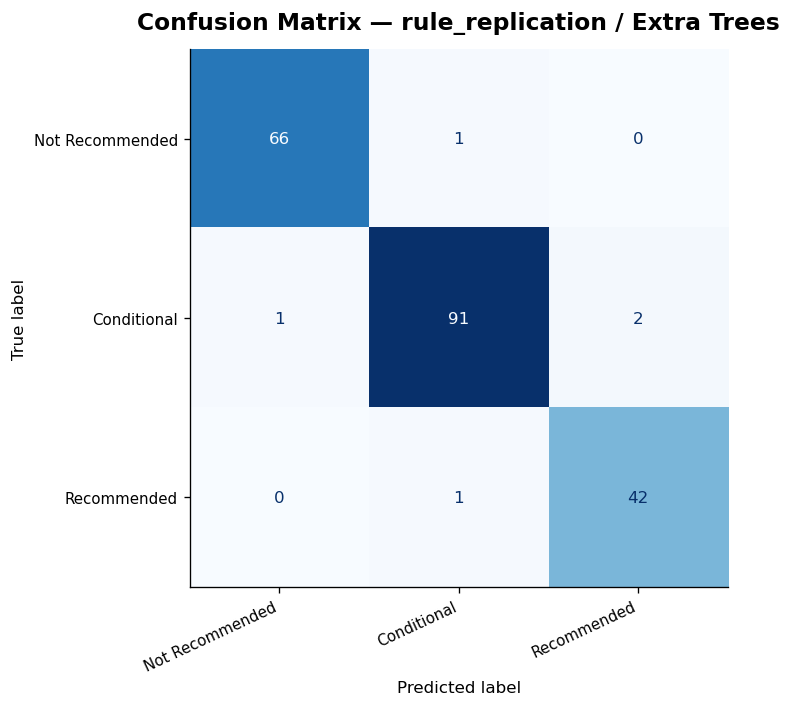

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\03_operational_prediction_confusion_matrix.png


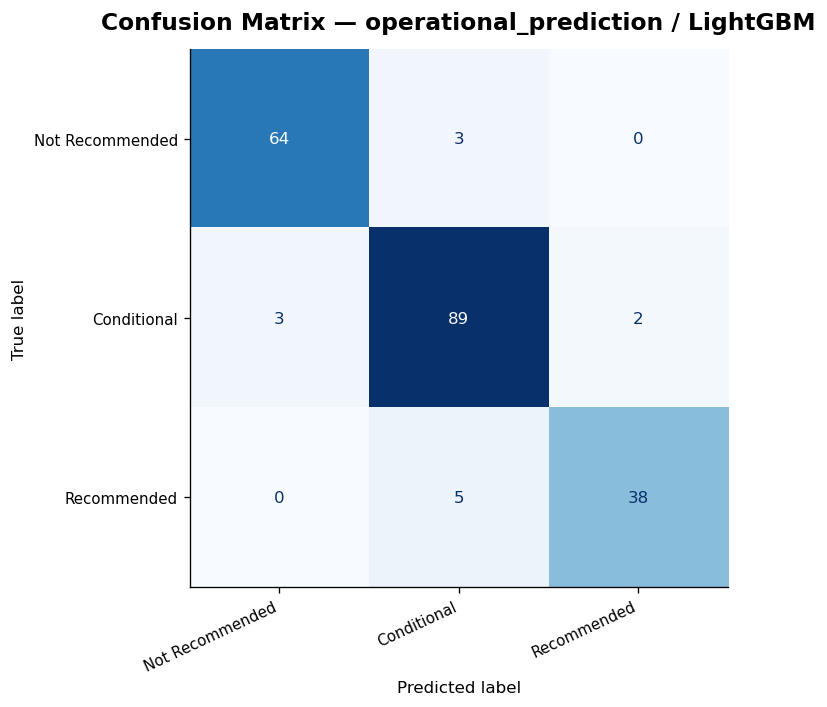

In [21]:
for mode, art in mode_artifacts.items():
    best_model_name = art['cv_results'].iloc[0]['model']
    best_pipe = art['pipes'][best_model_name]
    best_pipe.fit(art['X_train'], art['y_train'])
    y_pred = best_pipe.predict(art['X_test'])
    labels = [x for x in LABEL_ORDER if x in sorted(df[TARGET].unique(), key=lambda z: LABEL_ORDER.index(z) if z in LABEL_ORDER else 99)]
    cm = confusion_matrix(art['y_test'], y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(7.5, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f'Confusion Matrix — {mode} / {best_model_name}')
    plt.xticks(rotation=25, ha='right')
    savefig(f'03_{mode}_confusion_matrix.png')

## 9. Permutation feature importance for operational model

Feature importance difokuskan pada operational model karena model ini yang paling relevan untuk deployment dan decision support.

,feature,importance_mean,importance_std
5,margin,0.1841,0.0050
6,rc_ratio,0.0766,0.0081
34,cost_to_output_ratio,0.0646,0.0043
10,output_per_quantity,0.0341,0.0103
0,actor,0.0181,0.0003
9,cost_per_quantity,0.0164,0.0099
8,quantity_proxy,0.0121,0.0000
41,fertilizer_cost_share,0.0097,0.0026
40,seed_cost_share,0.0083,0.0028
12,asset_utilization,0.0061,0.0050


Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\03_operational_permutation_feature_importance.png


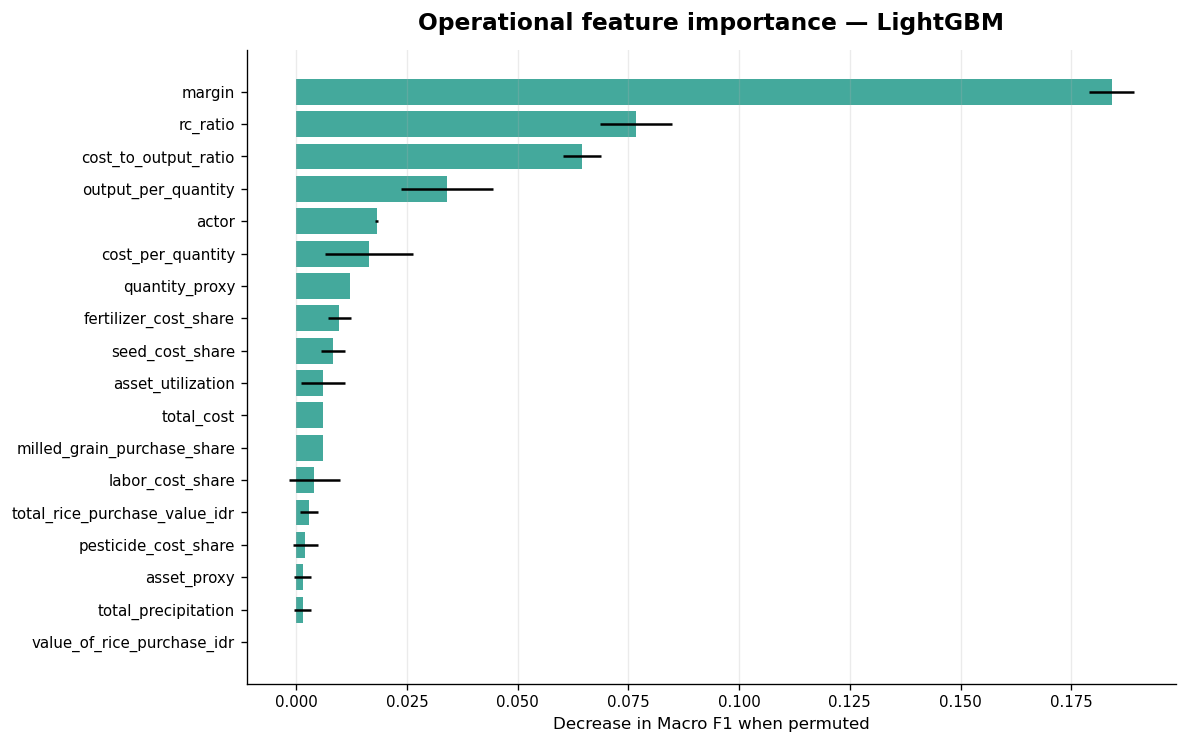

In [22]:
PRIMARY_MODE = 'operational_prediction'
primary_art = mode_artifacts[PRIMARY_MODE]
primary_model_name = primary_art['cv_results'].iloc[0]['model']
primary_pipe = primary_art['pipes'][primary_model_name]
primary_pipe.fit(primary_art['X_train'], primary_art['y_train'])

try:
    perm = permutation_importance(
        primary_pipe,
        primary_art['X_test'],
        primary_art['y_test'],
        n_repeats=3,
        random_state=42,
        scoring='f1_macro',
        n_jobs=None
    )
    imp = pd.DataFrame({
        'feature': primary_art['X_test'].columns,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
    }).sort_values('importance_mean', ascending=False)
    display(imp.head(20))
    imp.to_csv(OUTPUT_DIR / '03_operational_permutation_feature_importance.csv', index=False)

    top_imp = imp.head(18).sort_values('importance_mean')
    fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(top_imp))))
    ax.barh(top_imp['feature'], top_imp['importance_mean'], xerr=top_imp['importance_std'], color=COLORS['green'], alpha=0.88)
    ax.set_xlabel('Decrease in Macro F1 when permuted')
    ax.set_title(f'Operational feature importance — {primary_model_name}')
    ax.grid(axis='x')
    savefig('03_operational_permutation_feature_importance.png')
except Exception as e:
    print('Permutation importance skipped:', e)

## 10. Train final operational model and export

Model akhir dilatih ulang pada seluruh dataset menggunakan feature mode `operational_prediction`. Rule-replication model tetap dievaluasi sebagai sanity check, tetapi tidak dijadikan model deployment utama.

In [23]:
import joblib

# Rebuild final pipeline using all data in operational mode.
final_feature_cols = feature_modes[PRIMARY_MODE]
X_full = df[final_feature_cols].copy()
y_full = df[TARGET].copy()
preprocessor, final_num_features, final_cat_features = build_preprocessor(X_full)
final_models, _ = build_model_zoo()
final_model_name = primary_model_name
final_pipe = Pipeline(steps=[('preprocess', preprocessor), ('model', final_models[final_model_name])])
final_pipe.fit(X_full, y_full)

model_path = MODEL_DIR / 'riceguard_operational_best_model.joblib'
joblib.dump(final_pipe, model_path)

final_payload = {
    'notebook': '03_model_training_evaluation_REVISED_v5',
    'primary_mode': PRIMARY_MODE,
    'best_model': final_model_name,
    'feature_cols': final_feature_cols,
    'categorical_features': final_cat_features,
    'numeric_features': final_num_features,
    'target': TARGET,
    'label_order': label_order,
    'selection_metric': '0.60*MacroF1 + 0.40*BalancedAccuracy',
    'cv_note': 'Train-test split is performed before CV. Stratified K-Fold is run only on train set.',
    'evaluation_note': 'Target is pseudo label generated by Notebook 02. Evaluation is against pseudo labels, not external ground truth.',
    'mode_note': 'Operational mode excludes final readiness score, rule component scores, cluster support, votes, and stress-test survival flags.'
}
with open(MODEL_DIR / 'riceguard_operational_best_model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(final_payload, f, indent=2)

# Save a compact summary for reporting.
summary_payload = {
    'overall_best_cv': cv_results.iloc[0].to_dict(),
    'operational_best_cv': primary_art['cv_results'].iloc[0].to_dict(),
    'holdout_metrics_by_mode': holdout_results.to_dict(orient='records'),
    'optional_model_status': optional_status_df.to_dict(orient='records')
}
with open(OUTPUT_DIR / '03_revised_modeling_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_payload, f, indent=2)

print('Saved final operational model:', model_path)
print('Saved metadata:', MODEL_DIR / 'riceguard_operational_best_model_metadata.json')

Saved final operational model: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\models\riceguard_operational_best_model.joblib
Saved metadata: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\models\riceguard_operational_best_model_metadata.json


## 11. Final evaluation summary

Bagian ini menampilkan ranking model dan file output utama untuk submission.

In [24]:
print('Top CV models across both modes:')
display(cv_results[['mode','model','selection_score','f1_macro_mean','f1_macro_std','balanced_accuracy_mean','accuracy_mean','f1_weighted_mean','n_features']].head(12))

print()
print('Holdout metrics by mode:')
display(holdout_results)

print()
print('Primary operational model:')
print('-', primary_model_name)
print()
print('Generated Notebook 03 outputs:')
for p in sorted(OUTPUT_DIR.glob('03_*')):
    print('-', p)
print()
print('Generated model outputs:')
for p in sorted(MODEL_DIR.glob('riceguard_*')):
    print('-', p)

Top CV models across both modes:


,mode,model,selection_score,f1_macro_mean,f1_macro_std,balanced_accuracy_mean,accuracy_mean,f1_weighted_mean,n_features
0,rule_replication,Extra Trees,0.9565,0.9559,0.0095,0.9573,0.9591,0.9591,74
1,rule_replication,LightGBM,0.9478,0.9501,0.0057,0.9443,0.9525,0.9525,74
2,rule_replication,Random Forest,0.9474,0.9485,0.0075,0.9457,0.9525,0.9524,74
3,rule_replication,Decision Tree,0.9421,0.9404,0.0187,0.9445,0.9427,0.9429,74
4,rule_replication,CatBoost,0.9361,0.9395,0.0148,0.9310,0.9443,0.9440,74
5,rule_replication,XGBoost,0.9305,0.9332,0.0144,0.9263,0.9361,0.9360,74
6,operational_prediction,LightGBM,0.9303,0.9303,0.0130,0.9303,0.9345,0.9345,52
7,rule_replication,Gradient Boosting,0.9229,0.9253,0.0101,0.9193,0.9296,0.9295,74
8,operational_prediction,Random Forest,0.9227,0.9226,0.0165,0.9229,0.9264,0.9261,52
9,operational_prediction,Extra Trees,0.9227,0.9220,0.0233,0.9237,0.9231,0.9234,52



Holdout metrics by mode:


,mode,best_model,accuracy,balanced_accuracy,f1_macro,f1_weighted,n_features
0,operational_prediction,LightGBM,0.9363,0.9286,0.9343,0.9362,52
1,rule_replication,Extra Trees,0.9755,0.9766,0.9746,0.9755,74



Primary operational model:
- LightGBM

Generated Notebook 03 outputs:
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_all_modes_cv_model_comparison.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_best_model_classification_report.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_best_model_holdout_metrics.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_best_model_metadata.json
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_classification_report.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_cross_validation.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_cv_model_comparison.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_feature_importance.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_holdout_metrics_by_mode.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\03_holdout_predictions.csv
- c:\Users\USER\